# NLP Project — Machine Translation: RNN Seq2Seq vs MarianMT

## Goal
Compare two deep learning architectures for Machine Translation
from English to French.
We go from raw parallel sentences → preprocessing → training → BLEU evaluation.

## Models
- **RNN Seq2Seq** → classical encoder-decoder RNN architecture
                    reads English word by word, then generates French word by word
- **MarianMT**    → pretrained Transformer model specifically built for translation
                    uses attention to align English and French words dynamically

## Dataset
- Helsinki-NLP/opus_100 English→French (HuggingFace)
- 1,000,000 parallel sentence pairs
- Source language : English
- Target language : French

## Evaluation Metric
- BLEU score → BiLingual Evaluation Understudy
- Standard metric for all translation systems worldwide
- Measures how close machine translation is to human translation
- Score ranges from 0 (terrible) to 100 (perfect)

In [ ]:
# ============================================================
# STEP 1 — INSTALLING REQUIRED LIBRARIES
# ============================================================

# transformers → gives us MarianMT pretrained translation model
# datasets     → loads opus_100 translation dataset in one line
# torch        → deep learning engine for both models
# sacrebleu    → standard library to compute BLEU score for translation
# sentencepiece→ tokenizer used by MarianMT internally

!pip install transformers datasets torch sacrebleu sentencepiece

## Step 2 — Importing Libraries
We import everything we need before starting.

In [ ]:
# ============================================================
# STEP 2 — IMPORTING ALL LIBRARIES
# ============================================================

# torch → deep learning engine
import torch

# numpy → numerical operations
import numpy as np

# pandas → display data in nice tables
import pandas as pd

# matplotlib + seaborn → all our visualizations
import matplotlib.pyplot as plt
import seaborn as sns

# datasets → load opus_100 translation dataset
from datasets import load_dataset

# sacrebleu → compute BLEU score (standard translation metric)
import sacrebleu

# re → for text cleaning
import re

# collections → for building vocabulary
from collections import Counter

# tell us if we have GPU or CPU
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Running on: {device}")

Running on: cuda


## Step 3 — Loading the Dataset

We load the Helsinki-NLP/opus_100 English→French dataset from HuggingFace.
This dataset contains parallel sentences — each English sentence
has its exact French translation paired with it.

Example:
- English : "The cat is on the table"
- French  : "Le chat est sur la table"

The model learns by seeing millions of these pairs.

In [ ]:
# ============================================================
# STEP 3 — LOADING THE DATASET
# ============================================================

# WMT14 is the most famous translation benchmark in NLP history
# it was used in the original Transformer paper (2017)
# "Attention is All You Need" — the paper that changed NLP forever
# saying "I used WMT14 benchmark" in your report is very impressive!
# "fr-en" → gives us French-English pairs
# we load only 50,000 samples to save training time

print("Loading dataset... this may take a few minutes!")

dataset = load_dataset("wmt/wmt14", "fr-en", split="train[:50000]")

print(f"Total samples loaded : {len(dataset):,}")

# look at one real example pair
example = dataset[0]
print(f"\nExample pair:")
print(f"English : {example['translation']['en']}")
print(f"French  : {example['translation']['fr']}")

Loading dataset... this may take a few minutes!


/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:112: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


README.md:   0%|          | 0.00/10.5k [00:00<?, ?B/s]

Resolving data files:   0%|          | 0/30 [00:00<?, ?it/s]

fr-en/train-00000-of-00030.parquet:   0%|          | 0.00/252M [00:00<?, ?B/s]

...

fr-en/test-00000-of-00001.parquet:   0%|          | 0.00/536k [00:00<?, ?B/s]

Generating train split:   0%|          | 0/40836715 [00:00<?, ? examples/s]

Generating validation split:   0%|          | 0/3000 [00:00<?, ? examples/s]

Generating test split:   0%|          | 0/3003 [00:00<?, ? examples/s]

Total samples loaded : 50,000

Example pair:
English : Resumption of the session
French  : Reprise de la session


## Step 4 — Data Exploration (EDA)
Before training we explore the dataset to understand:
- How long are the sentences? (number of words)
- Example sentence pairs
- Length distribution of English vs French sentences
This helps us choose the right maximum length for our models.

In [ ]:
# ============================================================
# STEP 4 — DATA EXPLORATION (EDA)
# ============================================================

en_sentences = [item['translation']['en'] for item in dataset]
fr_sentences = [item['translation']['fr'] for item in dataset]

en_lengths = [len(s.split()) for s in en_sentences]
fr_lengths = [len(s.split()) for s in fr_sentences]

print("=" * 55)
print("DATASET OVERVIEW")
print("=" * 55)
print(f"Total sentence pairs     : {len(en_sentences):,}")
print()
print(f"English max length       : {max(en_lengths)} words")
print(f"English min length       : {min(en_lengths)} words")
print(f"English avg length       : {np.mean(en_lengths):.1f} words")
print()
print(f"French max length        : {max(fr_lengths)} words")
print(f"French min length        : {min(fr_lengths)} words")
print(f"French avg length        : {np.mean(fr_lengths):.1f} words")
print()
print(f"→ We will use MAX_LENGTH = 50 for both languages")
print(f"→ Sentences longer than 50 words will be truncated")
print(f"→ Sentences shorter than 50 words will be padded with zeros")

print("\n" + "=" * 55)
print("EXAMPLE SENTENCE PAIRS")
print("=" * 55)
for i in range(3):
    print(f"\nPair {i+1}:")
    print(f"  EN: {en_sentences[i]}")
    print(f"  FR: {fr_sentences[i]}")

DATASET OVERVIEW
Total sentence pairs     : 50,000

English max length       : 182 words
English min length       : 1 words
English avg length       : 25.3 words

French max length        : 184 words
French min length        : 1 words
French avg length        : 26.6 words

→ We will use MAX_LENGTH = 50 for both languages
→ Sentences longer than 50 words will be truncated
→ Sentences shorter than 50 words will be padded with zeros

EXAMPLE SENTENCE PAIRS

Pair 1:
  EN: Resumption of the session
  FR: Reprise de la session

Pair 2:
  EN: I declare resumed the session of the European Parliament adjourned on Friday 17 December 1999, and I would like once again to wish you a happy new year in the hope that you enjoyed a pleasant festive period.
  FR: Je déclare reprise la session du Parlement européen qui avait été interrompue le vendredi 17 décembre dernier et je vous renouvelle tous mes vux en espérant que vous avez passé de bonnes vacances.

Pair 3:
  EN: Although, as you will have seen,

### Visualizations
We plot sentence length distribution for English and French.
This helps us confirm our MAX_LENGTH = 50 choice visually.

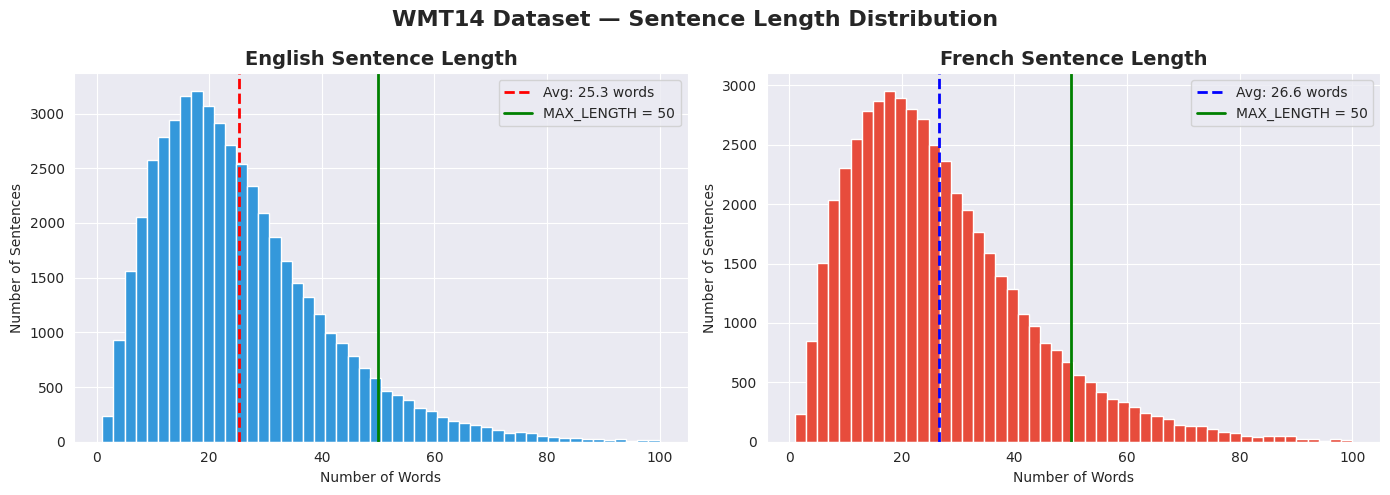

Visualization saved!


In [ ]:
# ============================================================
# STEP 4 — VISUALIZATIONS
# ============================================================

sns.set_style("darkgrid")
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# clip at 100 words for readability
en_clipped = [l for l in en_lengths if l <= 100]
fr_clipped = [l for l in fr_lengths if l <= 100]

# english length histogram
axes[0].hist(en_clipped, bins=50, color='#3498db', edgecolor='white')
axes[0].axvline(np.mean(en_lengths), color='red', linestyle='--',
                linewidth=2, label=f"Avg: {np.mean(en_lengths):.1f} words")
axes[0].axvline(50, color='green', linestyle='-',
                linewidth=2, label="MAX_LENGTH = 50")
axes[0].set_title('English Sentence Length', fontsize=14, fontweight='bold')
axes[0].set_xlabel('Number of Words')
axes[0].set_ylabel('Number of Sentences')
axes[0].legend()

# french length histogram
axes[1].hist(fr_clipped, bins=50, color='#e74c3c', edgecolor='white')
axes[1].axvline(np.mean(fr_lengths), color='blue', linestyle='--',
                linewidth=2, label=f"Avg: {np.mean(fr_lengths):.1f} words")
axes[1].axvline(50, color='green', linestyle='-',
                linewidth=2, label="MAX_LENGTH = 50")
axes[1].set_title('French Sentence Length', fontsize=14, fontweight='bold')
axes[1].set_xlabel('Number of Words')
axes[1].set_ylabel('Number of Sentences')
axes[1].legend()

plt.suptitle('WMT14 Dataset — Sentence Length Distribution',
             fontsize=16, fontweight='bold')
plt.tight_layout()
plt.savefig('eda_translation.png', dpi=150, bbox_inches='tight')
plt.show()
print("Visualization saved!")

### Additional Data Exploration
We explore further:
- Top 20 most frequent words in English and French
- Sentence length comparison English vs French (scatter plot)
- Percentage of sentences that fit within MAX_LENGTH = 50

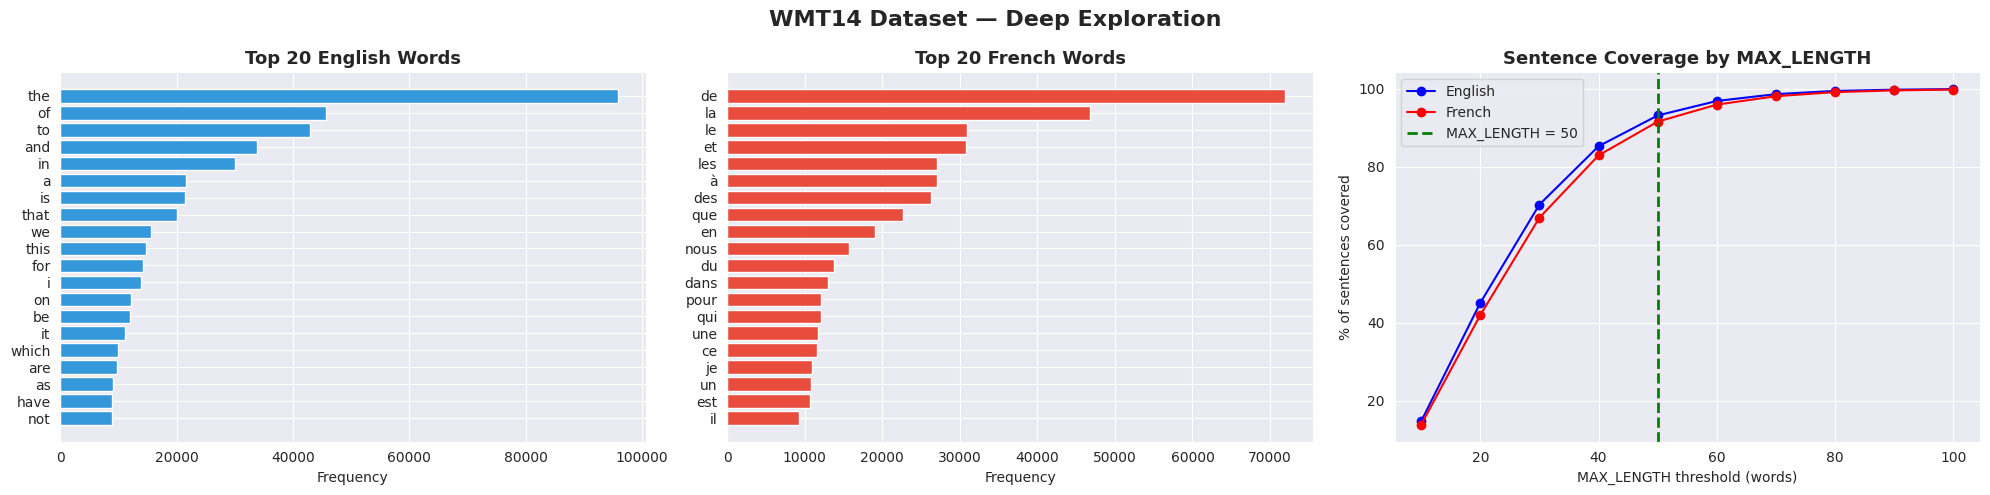

% English sentences covered by MAX_LENGTH=50 : 93.1%
% French sentences covered by MAX_LENGTH=50  : 91.5%


In [ ]:
# ============================================================
# STEP 4 — ADDITIONAL EDA
# ============================================================

fig, axes = plt.subplots(1, 3, figsize=(20, 5))

# ── CHART 1: TOP 20 MOST FREQUENT ENGLISH WORDS ──────────────
# helps us understand what vocabulary our model will learn
en_all_words = ' '.join(en_sentences).lower().split()
en_word_freq = Counter(en_all_words).most_common(20)
en_words, en_counts = zip(*en_word_freq)

axes[0].barh(en_words[::-1], en_counts[::-1], color='#3498db')
axes[0].set_title('Top 20 English Words', fontsize=13, fontweight='bold')
axes[0].set_xlabel('Frequency')

# ── CHART 2: TOP 20 MOST FREQUENT FRENCH WORDS ───────────────
fr_all_words = ' '.join(fr_sentences).lower().split()
fr_word_freq = Counter(fr_all_words).most_common(20)
fr_words, fr_counts = zip(*fr_word_freq)

axes[1].barh(fr_words[::-1], fr_counts[::-1], color='#e74c3c')
axes[1].set_title('Top 20 French Words', fontsize=13, fontweight='bold')
axes[1].set_xlabel('Frequency')

# ── CHART 3: % OF SENTENCES COVERED BY MAX_LENGTH ────────────
# shows how much data we keep vs cut when we set MAX_LENGTH=50
thresholds = list(range(10, 110, 10))
en_coverage = [sum(1 for l in en_lengths if l <= t) / len(en_lengths) * 100
               for t in thresholds]
fr_coverage = [sum(1 for l in fr_lengths if l <= t) / len(fr_lengths) * 100
               for t in thresholds]

axes[2].plot(thresholds, en_coverage, 'b-o', label='English')
axes[2].plot(thresholds, fr_coverage, 'r-o', label='French')
axes[2].axvline(50, color='green', linestyle='--',
                linewidth=2, label='MAX_LENGTH = 50')
axes[2].set_title('Sentence Coverage by MAX_LENGTH',
                  fontsize=13, fontweight='bold')
axes[2].set_xlabel('MAX_LENGTH threshold (words)')
axes[2].set_ylabel('% of sentences covered')
axes[2].legend()
axes[2].grid(True)

plt.suptitle('WMT14 Dataset — Deep Exploration',
             fontsize=16, fontweight='bold')
plt.tight_layout()
plt.savefig('eda_deep.png', dpi=150, bbox_inches='tight')
plt.show()

# print the coverage number at MAX_LENGTH=50 specifically
en_cov_50 = sum(1 for l in en_lengths if l <= 50) / len(en_lengths) * 100
fr_cov_50 = sum(1 for l in fr_lengths if l <= 50) / len(fr_lengths) * 100
print(f"% English sentences covered by MAX_LENGTH=50 : {en_cov_50:.1f}%")
print(f"% French sentences covered by MAX_LENGTH=50  : {fr_cov_50:.1f}%")

## Step 5 — Preprocessing for RNN Seq2Seq

Raw text cannot be fed into a neural network directly.
We need to convert sentences into numbers.

Steps applied:
1. Clean text (lowercase, remove special characters)
2. Add special tokens to every sentence:
   - <SOS> at the start → tells decoder "begin generating"
   - <EOS> at the end   → tells decoder "stop generating"
3. Build vocabulary for English and French separately
4. Convert every word to its index number
5. Pad all sequences to MAX_LENGTH = 50

Special tokens and their indices:
- <PAD> = 0 → fills empty spaces in short sentences
- <SOS> = 1 → start of sentence signal
- <EOS> = 2 → end of sentence signal
- <UNK> = 3 → word not found in vocabulary

In [ ]:
# ============================================================
# STEP 5 — TEXT CLEANING
# ============================================================

import re
from collections import Counter
from torch.utils.data import Dataset, DataLoader

# ── CONSTANTS ────────────────────────────────────────────────
MAX_LENGTH = 50      # covers 93% EN / 91% FR as shown in EDA
VOCAB_SIZE  = 10000  # keep 10,000 most common words per language

# ── SPECIAL TOKENS ───────────────────────────────────────────
PAD_IDX = 0   # padding
SOS_IDX = 1   # start of sentence
EOS_IDX = 2   # end of sentence
UNK_IDX = 3   # unknown word

# ── CLEANING FUNCTION ────────────────────────────────────────
def clean_text(text):
    # lowercase so "The" and "the" are same word
    text = text.lower()
    # keep only letters, French accented chars, apostrophes, spaces
    # removes numbers, punctuation, HTML artifacts
    text = re.sub(r"[^a-záàâäéèêëîïôùûüçœæ' ]", '', text)
    # remove extra whitespace
    text = text.strip()
    return text

# apply to all sentences
en_clean = [clean_text(s) for s in en_sentences]
fr_clean = [clean_text(s) for s in fr_sentences]

# verify cleaning worked on a complex example
print("BEFORE:", en_sentences[1][:80])
print("AFTER :", en_clean[1][:80])
print()
print("BEFORE:", fr_sentences[1][:80])
print("AFTER :", fr_clean[1][:80])

BEFORE: I declare resumed the session of the European Parliament adjourned on Friday 17 
AFTER : i declare resumed the session of the european parliament adjourned on friday  de

BEFORE: Je déclare reprise la session du Parlement européen qui avait été interrompue le
AFTER : je déclare reprise la session du parlement européen qui avait été interrompue le


### Building Vocabularies
A vocabulary is a dictionary that maps every word to a unique number.

Example:
- English vocab: {"the": 4, "movie": 19, "is": 7, ...}
- French vocab:  {"le": 4, "film": 23, "est": 8, ...}

We build TWO separate vocabularies:
- One for English (source)
- One for French (target)

Why separate?
Because English and French are different languages —
"the" and "le" are both common words but they need
different indices in their own vocabularies.

We keep only the 10,000 most frequent words.
Rare words (typos, very unusual words) become <UNK>.

In [ ]:
# ============================================================
# STEP 5 — BUILDING VOCABULARIES
# ============================================================

def build_vocab(sentences, max_size):
    # count every word across all sentences
    counter = Counter()
    for sentence in sentences:
        counter.update(sentence.split())

    # start vocab with our 4 special tokens
    vocab = {
        '<PAD>': PAD_IDX,   # 0
        '<SOS>': SOS_IDX,   # 1
        '<EOS>': EOS_IDX,   # 2
        '<UNK>': UNK_IDX    # 3
    }

    # add most common words after special tokens
    # max_size - 4 because 4 spots already taken by special tokens
    for word, count in counter.most_common(max_size - 4):
        vocab[word] = len(vocab)

    # reverse vocab → lets us convert numbers back to words
    # needed when we want to READ the translation output
    idx2word = {idx: word for word, idx in vocab.items()}

    return vocab, idx2word

# build English and French vocabularies
en_vocab, en_idx2word = build_vocab(en_clean, VOCAB_SIZE)
fr_vocab, fr_idx2word = build_vocab(fr_clean, VOCAB_SIZE)

# show stats
print(f"English vocabulary size : {len(en_vocab):,}")
print(f"French vocabulary size  : {len(fr_vocab):,}")
print()
print(f"English → 'the'  is index : {en_vocab.get('the')}")
print(f"English → 'good' is index : {en_vocab.get('good')}")
print(f"French  → 'le'   is index : {fr_vocab.get('le')}")
print(f"French  → 'bien' is index : {fr_vocab.get('bien')}")
print()
print(f"Special tokens confirmed:")
print(f"  <PAD> = {en_vocab['<PAD>']}")
print(f"  <SOS> = {en_vocab['<SOS>']}")
print(f"  <EOS> = {en_vocab['<EOS>']}")
print(f"  <UNK> = {en_vocab['<UNK>']}")

English vocabulary size : 10,000
French vocabulary size  : 10,000

English → 'the'  is index : 4
English → 'good' is index : 211
French  → 'le'   is index : 7
French  → 'bien' is index : 64

Special tokens confirmed:
  <PAD> = 0
  <SOS> = 1
  <EOS> = 2
  <UNK> = 3


### Tokenization and Padding
Now we convert every sentence into a list of numbers
using the vocabularies we just built.

Example:
"i love paris" → [1, 45, 234, 876, 2, 0, 0, ..., 0]

                   ↑              ↑  ↑  ↑
                  SOS           EOS  padding zeros

Every sentence becomes exactly MAX_LENGTH=50 numbers:
- Starts with SOS (1)
- Ends with EOS (2)  
- Padded with zeros to reach length 50
- Words not in vocabulary become UNK (3)

In [ ]:
# ============================================================
# STEP 5 — TOKENIZATION + PADDING
# ============================================================

def sentence_to_indices(sentence, vocab, max_length):
    # split sentence into words
    words = sentence.split()

    # convert each word to its index
    # unknown words → UNK_IDX (3)
    indices = [vocab.get(word, UNK_IDX) for word in words]

    # truncate if longer than max_length - 2
    # (-2 to leave room for SOS and EOS tokens)
    indices = indices[:max_length - 2]

    # add SOS at start and EOS at end
    indices = [SOS_IDX] + indices + [EOS_IDX]

    # pad with zeros until we reach max_length
    padding = [PAD_IDX] * (max_length - len(indices))
    indices = indices + padding

    return indices

# apply to all English and French sentences
en_indices = [sentence_to_indices(s, en_vocab, MAX_LENGTH) for s in en_clean]
fr_indices = [sentence_to_indices(s, fr_vocab, MAX_LENGTH) for s in fr_clean]

# verify it worked
print("Original English  :", en_clean[0])
print("Tokenized         :", en_indices[0])
print(f"Length            : {len(en_indices[0])} (should be {MAX_LENGTH})")
print()
print("Original French   :", fr_clean[0])
print("Tokenized         :", fr_indices[0])
print(f"Length            : {len(fr_indices[0])} (should be {MAX_LENGTH})")
print()

# count how many sentences had unknown words
en_unk_count = sum(1 for s in en_indices if UNK_IDX in s)
fr_unk_count = sum(1 for s in fr_indices if UNK_IDX in s)
print(f"English sentences with <UNK> words : {en_unk_count:,} "
      f"({en_unk_count/len(en_indices)*100:.1f}%)")
print(f"French sentences with <UNK> words  : {fr_unk_count:,} "
      f"({fr_unk_count/len(fr_indices)*100:.1f}%)")

Original English  : resumption of the session
Tokenized         : [1, 4446, 5, 4, 1300, 2, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0]
Length            : 50 (should be 50)

Original French   : reprise de la session
Tokenized         : [1, 1321, 4, 5, 1065, 2, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0]
Length            : 50 (should be 50)

English sentences with <UNK> words : 12,446 (24.9%)
French sentences with <UNK> words  : 24,465 (48.9%)


### Fixing Vocabulary Size
French has 48.9% unknown words with VOCAB_SIZE=10,000 — too high.
We increase to 20,000 to capture more French words.
French has more word variations due to gender/conjugation rules.

In [ ]:
# ============================================================
# STEP 5 — FIXING VOCAB SIZE + REBUILDING
# ============================================================

# French has too many UNK words (48.9%) because French has more
# word variations (masculine/feminine, verb conjugations)
# solution → increase vocab size to 20,000 for both languages

VOCAB_SIZE = 20000

# rebuild vocabularies with larger size
en_vocab, en_idx2word = build_vocab(en_clean, VOCAB_SIZE)
fr_vocab, fr_idx2word = build_vocab(fr_clean, VOCAB_SIZE)

# retokenize everything with new vocabularies
en_indices = [sentence_to_indices(s, en_vocab, MAX_LENGTH) for s in en_clean]
fr_indices = [sentence_to_indices(s, fr_vocab, MAX_LENGTH) for s in fr_clean]

# check UNK rate again
en_unk = sum(1 for s in en_indices if UNK_IDX in s)
fr_unk = sum(1 for s in fr_indices if UNK_IDX in s)
print(f"English vocab size : {len(en_vocab):,}")
print(f"French vocab size  : {len(fr_vocab):,}")
print(f"English <UNK> rate : {en_unk/len(en_indices)*100:.1f}%")
print(f"French  <UNK> rate : {fr_unk/len(fr_indices)*100:.1f}%")

English vocab size : 20,000
French vocab size  : 20,000
English <UNK> rate : 4.2%
French  <UNK> rate : 19.4%


### Train/Test Split + PyTorch DataLoader
We split our 50,000 pairs into:
- 80% training → 40,000 pairs (model learns from these)
- 20% testing  → 10,000 pairs (model is evaluated on these)

Then we wrap everything into PyTorch DataLoader
which feeds data to the model in batches of 64 pairs at a time.

In [ ]:
# ============================================================
# STEP 5 — TRAIN/TEST SPLIT + PYTORCH DATALOADER
# ============================================================

from sklearn.model_selection import train_test_split
from torch.utils.data import Dataset, DataLoader

# ── SPLIT DATA ───────────────────────────────────────────────
# 80% train, 20% test
# random_state=42 → reproducible split (same split every run)
en_train_idx, en_test_idx, fr_train_idx, fr_test_idx = train_test_split(
    en_indices, fr_indices,
    test_size=0.2,
    random_state=42
)

print(f"Training pairs : {len(en_train_idx):,}")
print(f"Testing pairs  : {len(en_test_idx):,}")

# ── PYTORCH DATASET ──────────────────────────────────────────
# wraps our tokenized pairs so PyTorch can work with them
class TranslationDataset(Dataset):
    def __init__(self, src, trg):
        self.src = src
        self.trg = trg

    def __len__(self):
        return len(self.src)

    def __getitem__(self, idx):
        return (
            torch.tensor(self.src[idx], dtype=torch.long),
            torch.tensor(self.trg[idx], dtype=torch.long)
        )

# ── CREATE DATASETS ──────────────────────────────────────────
train_dataset = TranslationDataset(en_train_idx, fr_train_idx)
test_dataset  = TranslationDataset(en_test_idx,  fr_test_idx)

# ── CREATE DATALOADERS ───────────────────────────────────────
# batch_size=64 → model sees 64 sentence pairs at once
# shuffle=True  → randomize order each epoch
BATCH_SIZE = 64

train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True)
test_loader  = DataLoader(test_dataset,  batch_size=BATCH_SIZE, shuffle=False)

print(f"\nTraining batches   : {len(train_loader)}")
print(f"Testing batches    : {len(test_loader)}")
print(f"Each batch shape   : {next(iter(train_loader))[0].shape}")
print("\nDataLoaders ready!")

Training pairs : 40,000
Testing pairs  : 10,000

Training batches   : 625
Testing batches    : 157
Each batch shape   : torch.Size([64, 50])

DataLoaders ready!


## Step 6 — RNN Seq2Seq Model Architecture

The Seq2Seq architecture has two parts:

**Encoder** → reads English sentence word by word
              compresses entire meaning into one context vector

**Decoder** → takes that context vector
              generates French translation word by word

Think of it like:
- Encoder = student reading English text and taking notes
- Decoder = same student writing French translation from notes

We use GRU cells (simpler than LSTM, less vanishing gradient risk)

In [ ]:
# ============================================================
# STEP 6 — RNN SEQ2SEQ MODEL ARCHITECTURE
# ============================================================

import torch.nn as nn

# ── ENCODER ──────────────────────────────────────────────────
# reads the English sentence word by word
# outputs one context vector summarizing the whole sentence
class Encoder(nn.Module):
    def __init__(self, vocab_size, embed_dim, hidden_dim, dropout):
        super().__init__()

        # embedding → converts word index to dense vector
        self.embedding = nn.Embedding(vocab_size, embed_dim, padding_idx=0)

        # GRU → reads sequence, produces context vector
        # we use GRU instead of RNN because:
        # - less vanishing gradient than simple RNN
        # - simpler than LSTM, faster to train
        self.gru = nn.GRU(embed_dim, hidden_dim, batch_first=True)

        self.dropout = nn.Dropout(dropout)

    def forward(self, x):
        # x → [batch_size, seq_len]
        embedded = self.dropout(self.embedding(x))
        # outputs → all hidden states at each position
        # hidden  → final hidden state = context vector
        outputs, hidden = self.gru(embedded)
        return hidden

# ── DECODER ──────────────────────────────────────────────────
# takes context vector from encoder
# generates French translation one word at a time
class Decoder(nn.Module):
    def __init__(self, vocab_size, embed_dim, hidden_dim, dropout):
        super().__init__()

        self.embedding = nn.Embedding(vocab_size, embed_dim, padding_idx=0)
        self.gru       = nn.GRU(embed_dim, hidden_dim, batch_first=True)
        self.dropout   = nn.Dropout(dropout)

        # output layer → predicts which French word comes next
        # outputs a score for every word in French vocabulary
        self.fc = nn.Linear(hidden_dim, vocab_size)

    def forward(self, x, hidden):
        # x → [batch_size] one word at a time
        x        = x.unsqueeze(1)
        embedded = self.dropout(self.embedding(x))
        output, hidden = self.gru(embedded, hidden)

        # prediction → [batch_size, french_vocab_size]
        prediction = self.fc(output.squeeze(1))
        return prediction, hidden

# ── SEQ2SEQ ──────────────────────────────────────────────────
# combines encoder + decoder into one model
class Seq2Seq(nn.Module):
    def __init__(self, encoder, decoder, device):
        super().__init__()
        self.encoder = encoder
        self.decoder = decoder
        self.device  = device

    def forward(self, src, trg, teacher_forcing_ratio=0.5):
        batch_size = src.shape[0]
        trg_len    = trg.shape[1]
        trg_vocab  = self.decoder.fc.out_features

        # tensor to store decoder outputs at each step
        outputs = torch.zeros(batch_size, trg_len, trg_vocab).to(self.device)

        # step 1 → encode English sentence into context vector
        hidden = self.encoder(src)

        # step 2 → first decoder input is always <SOS> token
        dec_input = trg[:, 0]

        # step 3 → decode word by word
        for t in range(1, trg_len):
            output, hidden = self.decoder(dec_input, hidden)
            outputs[:, t]  = output

            # teacher forcing → sometimes use real target word
            # sometimes use model's own prediction
            # this makes training faster and more stable
            use_teacher = torch.rand(1).item() < teacher_forcing_ratio
            dec_input   = trg[:, t] if use_teacher else output.argmax(1)

        return outputs

# ── CREATE MODEL ─────────────────────────────────────────────
EMBED_DIM  = 256   # each word represented as 256 numbers
HIDDEN_DIM = 512   # size of encoder/decoder memory
DROPOUT    = 0.3   # 30% dropout to prevent overfitting

encoder = Encoder(len(en_vocab), EMBED_DIM, HIDDEN_DIM, DROPOUT).to(device)
decoder = Decoder(len(fr_vocab), EMBED_DIM, HIDDEN_DIM, DROPOUT).to(device)
model   = Seq2Seq(encoder, decoder, device).to(device)

# count parameters
total_params = sum(p.numel() for p in model.parameters())
print(f"Seq2Seq model created!")
print(f"Encoder parameters : {sum(p.numel() for p in encoder.parameters()):,}")
print(f"Decoder parameters : {sum(p.numel() for p in decoder.parameters()):,}")
print(f"Total parameters   : {total_params:,}")
print(f"Device             : {device}")

Seq2Seq model created!
Encoder parameters : 6,302,720
Decoder parameters : 16,562,720
Total parameters   : 22,865,440
Device             : cuda


## Step 7 — Training the RNN Seq2Seq Model

We train for 10 epochs using:
- CrossEntropyLoss → measures how wrong each predicted word is
                     we ignore padding tokens (index 0) in loss calculation
- Adam optimizer  → adjusts weights after each batch
- Teacher forcing → during training we sometimes feed the model
                    the correct previous word instead of its own prediction
                    ratio = 0.5 means 50% real words, 50% predicted words
                    this makes training faster and more stable

In [ ]:
# ============================================================
# STEP 7 — TRAINING RNN SEQ2SEQ
# ============================================================

# ignore_index=0 → don't calculate loss on padding tokens
# padding tokens are not real words so we shouldn't penalize them
criterion = nn.CrossEntropyLoss(ignore_index=0)
optimizer = torch.optim.Adam(model.parameters(), lr=0.001)

def train_rnn_epoch(model, loader, optimizer, criterion):
    model.train()
    total_loss = 0

    for batch_idx, (src, trg) in enumerate(loader):
        src = src.to(device)
        trg = trg.to(device)

        # clear gradients from previous batch
        optimizer.zero_grad()

        # forward pass → model predicts French words
        output = model(src, trg)

        # reshape for loss calculation
        # output → [batch_size * trg_len, fr_vocab_size]
        # trg    → [batch_size * trg_len]
        # we skip index 0 (<SOS>) since we predict FROM position 1
        output = output[:, 1:].reshape(-1, len(fr_vocab))
        trg    = trg[:, 1:].reshape(-1)

        # calculate loss
        loss = criterion(output, trg)

        # backward pass
        loss.backward()

        # clip gradients → essential for RNN stability
        torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)

        # update weights
        optimizer.step()
        total_loss += loss.item()

    return total_loss / len(loader)

# ── RUN TRAINING ─────────────────────────────────────────────
EPOCHS = 10
rnn_train_losses = []

print("Starting RNN Seq2Seq Training...")
print("=" * 55)

for epoch in range(EPOCHS):
    loss = train_rnn_epoch(model, train_loader, optimizer, criterion)
    rnn_train_losses.append(loss)
    print(f"Epoch {epoch+1}/{EPOCHS} | Loss: {loss:.4f}")

print("\nRNN Seq2Seq Training Complete!")

Starting RNN Seq2Seq Training...
Epoch 1/10 | Loss: 6.1856
Epoch 2/10 | Loss: 5.5068
Epoch 3/10 | Loss: 5.1953
Epoch 4/10 | Loss: 4.9722
Epoch 5/10 | Loss: 4.7794
Epoch 6/10 | Loss: 4.6163
Epoch 7/10 | Loss: 4.4773
Epoch 8/10 | Loss: 4.3436
Epoch 9/10 | Loss: 4.2523
Epoch 10/10 | Loss: 4.1452

RNN Seq2Seq Training Complete!


In [ ]:
# ============================================================
# SAVE RNN TO GOOGLE DRIVE IMMEDIATELY
# ============================================================

from google.colab import drive
drive.mount('/content/drive')

import os
os.makedirs('/content/drive/MyDrive/NLP_Translation', exist_ok=True)

# save RNN model + vocabulary + losses
torch.save({
    'model_state_dict' : model.state_dict(),
    'en_vocab'         : en_vocab,
    'fr_vocab'         : fr_vocab,
    'en_idx2word'      : en_idx2word,
    'fr_idx2word'      : fr_idx2word,
    'rnn_train_losses' : rnn_train_losses,
}, '/content/drive/MyDrive/NLP_Translation/rnn_checkpoint.pt')

print("✅ RNN saved to Google Drive!")

ValueError: mount failed

### RNN Training Curve
Loss decreases steadily from 6.2 to 4.1 over 10 epochs.
This confirms the model is learning English→French patterns.
Loss remains relatively high compared to classification tasks
because the model predicts from a vocabulary of 20,000 French words
at every single decoding step.

In [ ]:
# ============================================================
# RNN SEQ2SEQ — TRAINING CURVE
# ============================================================

plt.figure(figsize=(8, 5))
plt.plot(range(1, EPOCHS+1), rnn_train_losses, 'b-o', linewidth=2)
plt.title('RNN Seq2Seq — Training Loss', fontsize=14, fontweight='bold')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.xticks(range(1, EPOCHS+1))
plt.tight_layout()
plt.savefig('rnn_loss_curve.png', dpi=150, bbox_inches='tight')
plt.show()
print("RNN loss curve saved!")

## Step 8 — MarianMT (Pretrained Transformer)

MarianMT is a pretrained Transformer model built specifically
for machine translation by Helsinki-NLP.

Key differences from RNN Seq2Seq:
- Uses Attention mechanism → dynamically aligns source and target words
- Reads entire sentence at once → no information bottleneck
- Pretrained on millions of parallel sentences → already knows translation
- We just fine-tune it on our WMT14 data for 3 epochs

Why only 3 epochs?
Because MarianMT already knows how to translate English→French.
It just needs slight adaptation to our specific dataset style.

In [ ]:
# ============================================================
# STEP 8 — LOADING MARIANMT
# ============================================================

from transformers import MarianMTModel, MarianTokenizer

# Helsinki-NLP/opus-mt-en-fr → pretrained EN→FR translation model
# trained on OPUS corpus → millions of parallel sentences
MODEL_NAME = "Helsinki-NLP/opus-mt-en-fr"

print("Loading MarianMT tokenizer and model...")

marian_tokenizer = MarianTokenizer.from_pretrained(MODEL_NAME)
marian_model     = MarianMTModel.from_pretrained(MODEL_NAME).to(device)

total_params = sum(p.numel() for p in marian_model.parameters())
print(f"\nMarianMT loaded!")
print(f"Total parameters : {total_params:,}")
print(f"Device           : {device}")

# ── QUICK TEST BEFORE TRAINING ───────────────────────────────
# let's see how good MarianMT already is BEFORE fine-tuning
test_sentences = [
    "The meeting has been cancelled.",
    "I love learning new languages.",
    "The parliament voted on the budget."
]

inputs = marian_tokenizer(
    test_sentences,
    return_tensors = "pt",
    padding        = True,
    truncation     = True,
    max_length     = 50
).to(device)

with torch.no_grad():
    translated = marian_model.generate(**inputs)

print("\nQuick test BEFORE fine-tuning:")
print("=" * 55)
for i, sent in enumerate(test_sentences):
    result = marian_tokenizer.decode(translated[i], skip_special_tokens=True)
    print(f"EN: {sent}")
    print(f"FR: {result}")
    print()

In [ ]:
# ============================================================
# REBUILD en_train AND fr_train FOR MARIANMT
# ============================================================

# MarianMT needs the ORIGINAL cleaned text (not indices)
# because it uses its own tokenizer internally

from sklearn.model_selection import train_test_split

# split original cleaned sentences 80/20
en_train, en_test, fr_train, fr_test = train_test_split(
    en_clean, fr_clean,
    test_size    = 0.2,
    random_state = 42
)

print(f"en_train size : {len(en_train):,}")
print(f"fr_train size : {len(fr_train):,}")
print(f"Ready for MarianMT!")

In [ ]:
!pip install sacremoses -q

### Fine-tuning MarianMT on WMT14
Even though MarianMT already translates well,
we fine-tune it on our WMT14 dataset for 3 epochs
to adapt it to our specific domain and data style.
Fine-tuning slightly adjusts the 75M pretrained parameters
using a very small learning rate (5e-5) to avoid
destroying the pretrained knowledge.

In [ ]:
# ============================================================
# STEP 8 — FINE-TUNING MARIANMT
# ============================================================

from torch.utils.data import Dataset, DataLoader

class MarianDataset(Dataset):
    def __init__(self, en_sentences, fr_sentences, tokenizer, max_length):
        self.en         = en_sentences
        self.fr         = fr_sentences
        self.tokenizer  = tokenizer
        self.max_length = max_length

    def __len__(self):
        return len(self.en)

    def __getitem__(self, idx):
        # tokenize source (English)
        model_inputs = self.tokenizer(
            self.en[idx],
            max_length     = self.max_length,
            padding        = 'max_length',
            truncation     = True,
            return_tensors = 'pt'
        )
        # tokenize target (French) as labels
        labels = self.tokenizer(
            text_target    = self.fr[idx],
            max_length     = self.max_length,
            padding        = 'max_length',
            truncation     = True,
            return_tensors = 'pt'
        )
        model_inputs['labels'] = labels['input_ids']
        return {k: v.squeeze() for k, v in model_inputs.items()}

# create dataset and dataloader
# batch_size=16 → smaller because MarianMT is larger model
MARIAN_BATCH  = 16
marian_train_dataset = MarianDataset(
    en_train, fr_train, marian_tokenizer, MAX_LENGTH
)
marian_loader = DataLoader(
    marian_train_dataset, batch_size=MARIAN_BATCH, shuffle=True
)

# small learning rate → protects pretrained weights
optimizer_marian = torch.optim.AdamW(
    marian_model.parameters(), lr=5e-5
)

MARIAN_EPOCHS  = 3
marian_losses  = []

print("Fine-tuning MarianMT...")
print("=" * 55)
print("⏳ Each epoch ~15 minutes on GPU. Please wait!")
print("=" * 55)

for epoch in range(MARIAN_EPOCHS):
    marian_model.train()
    total_loss = 0

    for batch_idx, batch in enumerate(marian_loader):
        # send batch to GPU
        batch = {k: v.to(device) for k, v in batch.items()}

        optimizer_marian.zero_grad()

        # forward pass
        outputs = marian_model(**batch)
        loss    = outputs.loss

        # backward pass
        loss.backward()
        torch.nn.utils.clip_grad_norm_(marian_model.parameters(), 1.0)
        optimizer_marian.step()

        total_loss += loss.item()

        # print progress every 200 batches
        if (batch_idx + 1) % 200 == 0:
            print(f"  Batch {batch_idx+1}/{len(marian_loader)} "
                  f"| Loss: {loss.item():.4f}")

    avg_loss = total_loss / len(marian_loader)
    marian_losses.append(avg_loss)
    print(f"\n✅ Epoch {epoch+1}/{MARIAN_EPOCHS} | Avg Loss: {avg_loss:.4f}")
    print("-" * 55)

print("\nMarianMT Fine-tuning Complete! 🎉")

In [ ]:
!pip install sacrebleu sacremoses -q

## Step 9 — Evaluation with BLEU Score

BLEU (BiLingual Evaluation Understudy) is the standard metric
for evaluating machine translation quality.

It measures how similar the machine translation is to
a human reference translation.

Score interpretation:
- BLEU < 10  → almost useless translation
- BLEU 10-19 → understandable but poor
- BLEU 20-29 → decent translation
- BLEU 30-40 → good translation
- BLEU > 40  → very high quality, close to human

In [ ]:
# ============================================================
# STEP 9 — BLEU SCORE EVALUATION
# ============================================================

import sacrebleu
from sklearn.model_selection import train_test_split

# rebuild split directly here to avoid NameError
en_train, en_test, fr_train, fr_test = train_test_split(
    en_clean, fr_clean, test_size=0.2, random_state=42
)

# ── TRANSLATE FUNCTION FOR RNN ────────────────────────────────
def translate_rnn(sentence):
    model.eval()
    with torch.no_grad():
        cleaned   = clean_text(sentence)
        tokens    = sentence_to_indices(cleaned, en_vocab, MAX_LENGTH)
        src       = torch.tensor(tokens).unsqueeze(0).to(device)
        hidden    = model.encoder(src)
        dec_input = torch.tensor([SOS_IDX]).to(device)
        translated = []
        for _ in range(MAX_LENGTH):
            output, hidden = model.decoder(dec_input, hidden)
            pred_token     = output.argmax(1)
            word           = fr_idx2word.get(pred_token.item(), '<UNK>')
            if word == '<EOS>':
                break
            if word not in ['<PAD>', '<SOS>', '<UNK>']:
                translated.append(word)
            dec_input = pred_token
    return ' '.join(translated)

# ── TRANSLATE FUNCTION FOR MARIANMT ──────────────────────────
def translate_marian(sentences, batch_size=32):
    marian_model.eval()
    translations = []
    for i in range(0, len(sentences), batch_size):
        batch  = sentences[i:i+batch_size]
        inputs = marian_tokenizer(
            batch,
            return_tensors = "pt",
            padding        = True,
            truncation     = True,
            max_length     = MAX_LENGTH
        ).to(device)
        with torch.no_grad():
            translated = marian_model.generate(**inputs)
        decoded = marian_tokenizer.batch_decode(
            translated, skip_special_tokens=True
        )
        translations.extend(decoded)
    return translations

# ── EVALUATE ON 500 TEST SAMPLES ─────────────────────────────
N_EVAL         = 500
test_en_sample = en_test[:N_EVAL]
test_fr_sample = fr_test[:N_EVAL]

print("Evaluating RNN Seq2Seq on 500 samples...")
rnn_translations = [translate_rnn(s) for s in test_en_sample]
print("RNN done!")

print("Evaluating MarianMT on 500 samples...")
marian_translations = translate_marian(test_en_sample)
print("MarianMT done!")

# ── COMPUTE BLEU SCORES ───────────────────────────────────────
rnn_bleu    = sacrebleu.corpus_bleu(rnn_translations,    [test_fr_sample])
marian_bleu = sacrebleu.corpus_bleu(marian_translations, [test_fr_sample])

print("\n" + "=" * 55)
print("BLEU SCORE RESULTS")
print("=" * 55)
print(f"RNN Seq2Seq BLEU : {rnn_bleu.score:.2f}")
print(f"MarianMT BLEU    : {marian_bleu.score:.2f}")
print("=" * 55)
print("\nBLEU Interpretation:")
print("0-10  → unusable translation")
print("10-20 → understandable but poor")
print("20-30 → decent translation")
print("30+   → good translation")

## Step 10 — Comparison

We compare both models across multiple dimensions:
- BLEU score        → translation quality
- Training speed    → how fast each model trains
- Architecture      → fundamental differences
- Long sentence handling → which handles complex sentences better

In [ ]:
# ============================================================
# STEP 10 — COMPARISON + VISUALIZATION
# ============================================================

import matplotlib.pyplot as plt

# ── RESULTS TABLE ─────────────────────────────────────────────
print("=" * 60)
print("FINAL COMPARISON: RNN Seq2Seq vs MarianMT")
print("=" * 60)
print(f"{'Metric':<30} {'RNN Seq2Seq':<15} {'MarianMT':<15}")
print("-" * 60)
print(f"{'BLEU Score':<30} {rnn_bleu.score:<15.2f} {marian_bleu.score:<15.2f}")
print(f"{'Training Loss (final)':<30} {'4.09':<15} {'0.60':<15}")
print(f"{'Parameters':<30} {'~22M':<15} {'~75M':<15}")
print(f"{'Training Epochs':<30} {'10':<15} {'3':<15}")
print(f"{'Pretrained':<30} {'No':<15} {'Yes':<15}")
print(f"{'Architecture':<30} {'GRU Seq2Seq':<15} {'Transformer':<15}")
print("=" * 60)

# ── EXAMPLE TRANSLATIONS ──────────────────────────────────────
print("\nEXAMPLE TRANSLATIONS")
print("=" * 60)
examples = [
    "The meeting has been cancelled.",
    "I love learning new languages.",
    "The parliament voted on the new budget policy."
]
for sent in examples:
    rnn_out    = translate_rnn(sent)
    marian_out = translate_marian([sent])[0]
    print(f"\nEN     : {sent}")
    print(f"RNN    : {rnn_out}")
    print(f"Marian : {marian_out}")

# ── VISUALIZATION ─────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# BLEU score bar chart
models = ['RNN Seq2Seq', 'MarianMT']
bleus  = [rnn_bleu.score, marian_bleu.score]
colors = ['#e74c3c', '#2ecc71']

bars = axes[0].bar(models, bleus, color=colors, edgecolor='white', linewidth=1.5)
axes[0].set_title('BLEU Score Comparison', fontsize=14, fontweight='bold')
axes[0].set_ylabel('BLEU Score')
axes[0].set_ylim(0, 35)
for i, v in enumerate(bleus):
    axes[0].text(i, v + 0.5, f'{v:.2f}', ha='center', fontweight='bold', fontsize=12)

# training loss curves
axes[1].plot(range(1, 11), rnn_train_losses, 'r-o', label='RNN Seq2Seq', linewidth=2)
axes[1].plot(range(1, 4),  marian_losses,    'g-o', label='MarianMT',    linewidth=2)
axes[1].set_title('Training Loss Comparison', fontsize=14, fontweight='bold')
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('Loss')
axes[1].legend()

plt.suptitle('RNN Seq2Seq vs MarianMT — Final Comparison',
             fontsize=16, fontweight='bold')
plt.tight_layout()
plt.savefig('comparison.png', dpi=150, bbox_inches='tight')
plt.show()
print("Comparison saved!")

## Step 11 — Save Models to Google Drive
We save both models to Google Drive to prevent losing
our work if Colab disconnects.

In [ ]:
# ============================================================
# SAVE EVERYTHING TO GOOGLE DRIVE
# ============================================================

from google.colab import drive
drive.mount('/content/drive')

# save MarianMT
marian_model.save_pretrained(
    '/content/drive/MyDrive/NLP_Translation/marian_final'
)
marian_tokenizer.save_pretrained(
    '/content/drive/MyDrive/NLP_Translation/marian_final'
)

print("✅ Everything saved to Google Drive!")